<a href="https://colab.research.google.com/github/etnshia123/NC_GPT_IMPORVED/blob/main/NC_GPT_v0_00_008_alpha_dev_experimental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install torch torchtyping matplotlib

  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.5.1
    Uninstalling typeguard-4.5.1:
      Successfully uninstalled typeguard-4.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [ ]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA is available! Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("CUDA not available, using CPU")

CUDA is available! Using GPU: Tesla T4


In [ ]:
import torch
from torchtyping import TensorType
from typing import Tuple

class Solution:
    def create_batches(self, data: TensorType[int], context_length: int, batch_size: int) -> Tuple[TensorType[int], TensorType[int]]:
        # Removed torch.manual_seed(0)
        ix = torch.randint(len(data) - context_length, (batch_size,))
        x = torch.stack([data[i:i + context_length] for i in ix])
        y = torch.stack([data[i + 1:i + 1 + context_length] for i in ix])
        return x, y

In [ ]:
# data/nlp_preprocessing.py
import torch
import torch.nn as nn
from torchtyping import TensorType
from typing import List

class Solution:
    def get_dataset(self, positive: List[str], negative: List[str]) -> TensorType[float]:
        combined = positive + negative

        # Build vocabulary: sorted unique words -> integer IDs starting at 1
        vocabulary = sorted({word for sentence in combined for word in sentence.split()})
        word_to_id = {word: idx + 1 for idx, word in enumerate(vocabulary)}

        # Encode each sentence as a tensor of word IDs
        encoded = [torch.tensor([word_to_id[w] for w in s.split()]) for s in combined]

        # Pad shorter sequences with 0s so output is a rectangular tensor
        return nn.utils.rnn.pad_sequence(encoded, batch_first=True)

In [ ]:
# data/tokenizer.py
from typing import List


class Solution:
    def get_merges(self, corpus: str, num_merges: int) -> List[List[str]]:
        tokens = list(corpus)
        merges = []
        for _ in range(num_merges):
            if len(tokens) < 2:
                break
            # Count adjacent pair frequencies
            pairs = {}
            for i in range(len(tokens) - 1):
                pair = (tokens[i], tokens[i + 1])
                pairs[pair] = pairs.get(pair, 0) + 1

            if not pairs:
                break

            # Find most frequent pair (tiebreak: lexicographically smallest)
            best_count = max(pairs.values())
            candidates = sorted(p for p, c in pairs.items() if c == best_count)
            best = candidates[0]

            merges.append([best[0], best[1]])

            # Merge all non-overlapping occurrences left to right
            new_tokens = []
            i = 0
            while i < len(tokens):
                if i < len(tokens) - 1 and tokens[i] == best[0] and tokens[i + 1] == best[1]:
                    new_tokens.append(best[0] + best[1])
                    i += 2
                else:
                    new_tokens.append(tokens[i])
                    i += 1
            tokens = new_tokens

        return merges

In [ ]:
# data/vocab.py
from typing import Dict, List, Tuple

class Solution:
    def build_vocab(self, text: str) -> Tuple[Dict[str, int], Dict[int, str]]:
        chars = sorted(set(text))
        stoi = {ch: i for i, ch in enumerate(chars)}
        itos = {i: ch for ch, i in stoi.items()}
        return stoi, itos

    def encode(self, text: str, stoi: Dict[str, int]) -> List[int]:
        return [stoi[ch] for ch in text]

    def decode(self, ids: List[int], itos: Dict[int, str]) -> str:
        return ''.join(itos[i] for i in ids)

In [ ]:
# data/__init__.py
# from .tokenizer import *
# from .vocab import *
# from .loader import *
# from .dataset import *
# from .nlp_preprocessing import *

In [ ]:
import torch
import torch.nn as nn
from torchtyping import TensorType

class SingleHeadAttention(nn.Module):

    def __init__(self, embedding_dim: int, attention_dim: int):
        super().__init__()
        # Removed torch.manual_seed(0)
        self.key_gen = nn.Linear(embedding_dim, attention_dim, bias=False)
        self.query_gen = nn.Linear(embedding_dim, attention_dim, bias=False)
        self.value_gen = nn.Linear(embedding_dim, attention_dim, bias=False)

    def forward(self, embedded: TensorType[float]) -> TensorType[float]:
        # Project input into Key, Query, Value spaces
        k = self.key_gen(embedded)   # (B, T, attention_dim)
        q = self.query_gen(embedded) # (B, T, attention_dim)
        v = self.value_gen(embedded) # (B, T, attention_dim)

        # Attention scores: (Q @ K^T) / sqrt(d_k)
        scores = q @ torch.transpose(k, 1, 2)
        context_length, attention_dim = k.shape[1], k.shape[2]
        scores = scores / (attention_dim ** 0.5)

        # Causal mask: prevent attending to future tokens
        lower_triangular = torch.tril(torch.ones(context_length, context_length, device=embedded.device))
        mask = lower_triangular == 0
        scores = scores.masked_fill(mask, float('-inf'))
        scores = nn.functional.softmax(scores, dim=2)

        return scores @ v

In [ ]:
# model/embeddings.py
import numpy as np
from numpy.typing import NDArray


class Solution:
    def lookup(self, embeddings: NDArray[np.float64], token_ids: NDArray[np.int64]) -> NDArray[np.float64]:
        return np.round(embeddings[token_ids], 5)

In [ ]:
import torch
import torch.nn as nn
from torchtyping import TensorType

class RotaryPositionalEmbedding(nn.Module):
    def __init__(self, dim, max_position_embeddings=2048, base=10000):
        super().__init__()
        self.dim = dim
        self.max_position_embeddings = max_position_embeddings
        self.base = base
        inv_freq = 1.0 / (self.base ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq)
        self._set_cos_sin_cache(seq_len=max_position_embeddings)

    def _set_cos_sin_cache(self, seq_len):
        self.max_seq_len_cached = seq_len
        t = torch.arange(seq_len, device=self.inv_freq.device, dtype=self.inv_freq.dtype)
        freqs = torch.einsum("i,j->ij", t, self.inv_freq)
        # Different from paper, but used in many implementations (like GPT-NeoX, LLama)
        emb = torch.cat((freqs, freqs), dim=-1)
        self.register_buffer("cos_cached", emb.cos()[None, None, :, :], persistent=False)
        self.register_buffer("sin_cached", emb.sin()[None, None, :, :], persistent=False)

    def forward(self, q, k, position_ids=None):
        # q, k: (B, H, T, D)
        seq_len_q = q.shape[-2] # This is T (current query length)
        max_abs_pos = -1

        if position_ids is not None:
            # Get the maximum absolute position that needs to be covered by the cache
            max_abs_pos = position_ids.max().item()

        # Determine the required cache length. It must cover either the current query length
        # or the maximum absolute position requested by position_ids, whichever is greater.
        required_cache_len = max(seq_len_q, max_abs_pos + 1)

        if required_cache_len > self.max_seq_len_cached:
            self._set_cos_sin_cache(seq_len=required_cache_len)

        if position_ids is None:
            cos = self.cos_cached[:, :, :seq_len_q, ...].to(q.dtype)
            sin = self.sin_cached[:, :, :seq_len_q, ...].to(q.dtype)
        else:
            # The indexing now correctly uses position_ids against the expanded cache
            indexed_cos = self.cos_cached.squeeze(0).squeeze(0)[position_ids]
            indexed_sin = self.sin_cached.squeeze(0).squeeze(0)[position_ids]

            cos = indexed_cos.unsqueeze(1).to(q.dtype) # (B_ids, 1, T, D)
            sin = indexed_sin.unsqueeze(1).to(q.dtype) # (B_ids, 1, T, D)

        q_embed = (q * cos) + (self._rotate_half(q) * sin)
        k_embed = (k * cos) + (self._rotate_half(k) * sin)
        return q_embed, k_embed

    def _rotate_half(self, x):
        x1 = x[..., : x.shape[-1] // 2]
        x2 = x[..., x.shape[-1] // 2 :]
        return torch.cat((-x2, x1), dim=-1)

In [ ]:
import torch
import torch.nn as nn
from torchtyping import TensorType
from typing import Optional, Tuple

class GPT(nn.Module):
    def __init__(self, vocab_size: int, context_length: int, model_dim: int, num_blocks: int, num_heads: int, num_kv_heads: Optional[int] = None):
        super().__init__()
        self.word_embeddings = nn.Embedding(vocab_size, model_dim)
        # Removed self.position_embeddings = nn.Embedding(context_length, model_dim)
        self.context_length = context_length # Store context_length for modulo operation

        # Use num_heads for KV if not specified (Standard Multi-Head Attention)
        kv_heads = num_kv_heads if num_kv_heads is not None else num_heads

        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(model_dim, num_heads, kv_heads) for _ in range(num_blocks)
        ])
        self.final_norm = nn.LayerNorm(model_dim)
        self.vocab_projection = nn.Linear(model_dim, vocab_size)
        self.vocab_projection.weight = self.word_embeddings.weight

        # Initialize RoPE
        self.rope = RotaryPositionalEmbedding(model_dim // num_heads, max_position_embeddings=context_length)


    def forward(self, context: TensorType[int], past_key_values: Optional[list] = None) -> Tuple[TensorType[float], list]:
        B, T = context.shape
        start_pos = 0
        if past_key_values is not None:
            start_pos = past_key_values[0][0].shape[2] # Assuming kv_cache is (B, H, S, D)

        embedded = self.word_embeddings(context)
        # Removed traditional positional embeddings application:
        # positions = torch.arange(start_pos, start_pos + T, device=context.device) % self.context_length
        # embedded = embedded + self.position_embeddings(positions)

        # Prepare position_ids for RoPE
        position_ids = torch.arange(start_pos, start_pos + T, dtype=torch.long, device=context.device).unsqueeze(0)

        new_past_key_values = []
        x = embedded
        for i, block in enumerate(self.transformer_blocks):
            layer_past = past_key_values[i] if past_key_values is not None else None
            x, kv_cache = block(x, self.rope, position_ids, layer_past)
            new_past_key_values.append(kv_cache)

        logits = self.vocab_projection(self.final_norm(x))
        return logits, new_past_key_values

In [ ]:
import torch
import torch.nn as nn
from torchtyping import TensorType

class MultiHeadedSelfAttention(nn.Module):

    def __init__(self, embedding_dim: int, attention_dim: int, num_heads: int):
        super().__init__()
        # Removed torch.manual_seed(0)
        self.att_heads = nn.ModuleList()
        for i in range(num_heads):
            self.att_heads.append(self.SingleHeadAttention(embedding_dim, attention_dim // num_heads))
        self.output_proj = nn.Linear(model_dim, model_dim)

    def forward(self, embedded: TensorType[float]) -> TensorType[float]:
        head_outputs = []
        for head in self.att_heads:
            head_outputs.append(head(embedded))
        concatenated = torch.cat(head_outputs, dim = 2)
        return self.output_proj(concatenated)

    class SingleHeadAttention(nn.Module):
        def __init__(self, embedding_dim: int, attention_dim: int):
            super().__init__()
            # Removed torch.manual_seed(0)
            self.key_gen = nn.Linear(embedding_dim, attention_dim, bias=False)
            self.query_gen = nn.Linear(embedding_dim, attention_dim, bias=False)
            self.value_gen = nn.Linear(embedding_dim, attention_dim, bias=False)

        def forward(self, embedded: TensorType[float]) -> TensorType[float]:
            k = self.key_gen(embedded)
            q = self.query_gen(embedded)
            v = self.value_gen(embedded)

            scores = q @ torch.transpose(k, 1, 2) # @ is the same as torch.matmul()
            context_length, attention_dim = k.shape[1], k.shape[2]
            scores = scores / (attention_dim ** 0.5)

            lower_triangular = torch.tril(torch.ones(context_length, context_length, device=embedded.device))
            mask = lower_triangular == 0
            scores = scores.masked_fill(mask, float('-inf'))
            scores = nn.functional.softmax(scores, dim = 2)

            return scores @ v

In [ ]:
# model/normalization.py
import numpy as np
from numpy.typing import NDArray


class Solution:
    def forward(self, x: NDArray[np.float64], gamma: NDArray[np.float64], beta: NDArray[np.float64]) -> NDArray[np.float64]:
        eps = 1e-5
        mean = np.mean(x)
        var = np.var(x)
        x_norm = (x - mean) / np.sqrt(var + eps)
        out = gamma * x_norm + beta
        return np.round(out, 5)

In [ ]:
# model/positional_encoding.py
import numpy as np
from numpy.typing import NDArray


class Solution:
    def get_positional_encoding(self, seq_len: int, d_model: int) -> NDArray[np.float64]:
        PE = np.zeros((seq_len, d_model))
        position = np.arange(seq_len).reshape(-1, 1)       # (seq_len, 1)
        div_term = 10000 ** (np.arange(0, d_model, 2) / d_model)  # (d_model/2,)
        PE[:, 0::2] = np.sin(position / div_term)           # Even indices: sine
        PE[:, 1::2] = np.cos(position / div_term[:PE[:, 1::2].shape[1]])  # Odd indices: cosine
        return np.round(PE, 5)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchtyping import TensorType
from typing import Optional, Tuple

class TransformerBlock(nn.Module):
    def __init__(self, model_dim: int, num_heads: int, num_kv_heads: int):
        super().__init__()
        self.attention = GroupedQueryAttention(model_dim, num_heads, num_kv_heads)
        self.linear_network = VanillaNeuralNetwork(model_dim)
        self.first_norm = nn.LayerNorm(model_dim)
        self.second_norm = nn.LayerNorm(model_dim)

    def forward(self, x: TensorType[float], rope: nn.Module, position_ids: torch.Tensor, past_key_value: Optional[Tuple[torch.Tensor, torch.Tensor]] = None) -> Tuple[TensorType[float], Tuple[torch.Tensor, torch.Tensor]]:
        attn_out, kv_cache = self.attention(self.first_norm(x), rope, position_ids, past_key_value)
        x = x + attn_out
        x = x + self.linear_network(self.second_norm(x))
        return x, kv_cache

class GroupedQueryAttention(nn.Module):
    def __init__(self, model_dim: int, num_heads: int, num_kv_heads: int):
        super().__init__()
        self.num_heads = num_heads
        self.num_kv_heads = num_kv_heads
        self.head_dim = model_dim // num_heads
        self.num_queries_per_kv = num_heads // num_kv_heads

        self.q_proj = nn.Linear(model_dim, num_heads * self.head_dim, bias=False)
        self.k_proj = nn.Linear(model_dim, num_kv_heads * self.head_dim, bias=False)
        self.v_proj = nn.Linear(model_dim, num_kv_heads * self.head_dim, bias=False)
        self.out_proj = nn.Linear(num_heads * self.head_dim, model_dim, bias=False)

    def forward(self, x: torch.Tensor, rope: nn.Module, position_ids: torch.Tensor, past_key_value: Optional[Tuple[torch.Tensor, torch.Tensor]] = None) -> Tuple[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        B, T, C = x.shape

        q = self.q_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.num_kv_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.num_kv_heads, self.head_dim).transpose(1, 2)

        # Apply RoPE
        q, k = rope(q, k, position_ids)

        if past_key_value is not None:
            past_k, past_v = past_key_value
            k = torch.cat([past_k, k], dim=2)
            v = torch.cat([past_v, v], dim=2)

        kv_cache = (k, v)

        # Repeat Keys and Values for GQA if necessary
        k_rep = k.repeat_interleave(self.num_queries_per_kv, dim=1)
        v_rep = v.repeat_interleave(self.num_queries_per_kv, dim=1)

        # Standard scaled dot-product attention
        attn = (q @ k_rep.transpose(-2, -1)) * (self.head_dim ** -0.5)

        # Causal Masking (only needed during training or if T > 1) or for the first token in generation
        # The condition needs to be adjusted to always apply causal masking when relevant
        if T > 1 or past_key_value is None: # This covers training (T>1) and initial generation (T=1, past_kv=None)
            # The mask needs to be (T_query, T_key_total)
            query_len = T
            key_len = k.shape[2] # This is the total sequence length of keys (past + current)

            # Create a base causal mask for the current query window (query_len x query_len)
            mask_base = (torch.tril(torch.ones(query_len, query_len, device=x.device)) == 0)

            if key_len > query_len: # This means we are doing incremental generation after the first token
                # Create a full mask of query_len x key_len. Past tokens should not be masked.
                # The mask for the past tokens should be all False (can attend).
                full_mask = torch.zeros(query_len, key_len, device=x.device, dtype=torch.bool)
                # Apply the causal mask to the current (last) 'query_len' positions of the key sequence
                full_mask[:, (key_len - query_len):] = mask_base
                mask = full_mask
            else: # Training or first token generation (key_len == query_len)
                mask = mask_base

            # Explicitly expand mask to match attn's full shape (B, H, T_query, T_key_total)
            mask = mask.unsqueeze(0).unsqueeze(0).expand(B, self.num_heads, query_len, key_len)

            attn = attn.masked_fill(mask, float('-inf'))

        attn = F.softmax(attn, dim=-1)
        out = (attn @ v_rep).transpose(1, 2).reshape(B, T, C)
        return self.out_proj(out), kv_cache

class VanillaNeuralNetwork(nn.Module):
    def __init__(self, model_dim: int):
        super().__init__()
        self.up_projection = nn.Linear(model_dim, model_dim * 6) # Changed from 4 to 6
        self.relu = nn.ReLU()
        self.down_projection = nn.Linear(model_dim * 6, model_dim) # Changed from 4 to 6
        self.dropout = nn.Dropout(0.2)

    def forward(self, x: TensorType[float]) -> TensorType[float]:
        return self.dropout(self.down_projection(self.relu(self.up_projection(x))))

In [ ]:
# model/__init__.py
# from .attention import *
# from .multi_head_attention import *
# from .transformer import *
# from .gpt import *
# from .normalization import *
# from .embeddings import *
# from .positional_encoding import *

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim.lr_scheduler

class TrainerSolution:
    def train(self, model: nn.Module, data: torch.Tensor, epochs: int, context_length: int, batch_size: int, lr: float, warmup_steps: int, scheduler_total_steps: int) -> float:
        # Calculate and print total parameters
        total_params = sum(p.numel() for p in model.parameters()) / 1e6
        print(f"Model initialized with {total_params:.2f}M parameters")

        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

        # Initialize Cosine Decay with Warmup scheduler
        cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=scheduler_total_steps - warmup_steps)
        warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1e-5, end_factor=1.0, total_iters=warmup_steps)
        scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[warmup_steps])

        losses = []

        for epoch in range(epochs):
            torch.manual_seed(epoch)
            ix = torch.randint(len(data) - context_length, (batch_size,))
            x = torch.stack([data[i:i + context_length] for i in ix])
            y = torch.stack([data[i + 1:i + 1 + context_length] for i in ix])

            x = x.to(device)
            y = y.to(device)

            # Unpack the tuple: (logits, past_key_values)
            logits, _ = model(x)

            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), y.view(B * T))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step() # Step the scheduler after each optimizer step

            current_loss = round(loss.item(), 4)
            losses.append(current_loss)

            # Print progress every 10% of epochs
            report = max(1, epochs // 10)
            if epoch % report == 0:
                print(f"Epoch {epoch}: loss {current_loss:.4f}, lr {optimizer.param_groups[0]['lr']:.6f}")

        return losses

In [ ]:
import random
from typing import List
import torch

class GeneratorSolution:
    def generate(self, model, new_chars: int, context: torch.Tensor, context_length: int,
              int_to_char: dict, word_to_int: dict, data: torch.Tensor, temperature: float = None, top_k: int = None, top_p: float = None,
              repetition_penalty: float = None, reset_prob: float = None, sentence_endings: str = ".!?") -> List[str]:
        result = []
        # Initialize past_key_values for KV-caching
        past_key_values = None

        for _ in range(new_chars):
            # Occasionally reset context at sentence boundaries
            if len(result) > 0 and result[-1] in sentence_endings:
                if reset_prob is not None and random.random() < reset_prob:
                    start_idx = torch.randint(0, len(data) - context_length, (1,))
                    new_context_segment = data[start_idx:start_idx + context_length].unsqueeze(0)
                    context = new_context_segment.to(next(model.parameters()).device)
                    past_key_values = None # Clear cache on reset

            # If we have a cache, we only need the last token
            if past_key_values is not None:
                model_input = context[:, -1:]
            else:
                # Otherwise, ensure context is not longer than context_length
                if context.shape[1] > context_length:
                    context = context[:, -context_length:]
                model_input = context

            # Forward pass: model now returns (logits, new_past_key_values)
            logits, past_key_values = model(model_input, past_key_values)

            # Focus on the last time step
            logits = logits[:, -1, :]

            # Apply repetition penalty
            if repetition_penalty is not None and repetition_penalty != 1.0:
                for prev_word in set(result[-10:]): # Penalize recently used words
                    if prev_word in word_to_int:
                        prev_token_id = word_to_int[prev_word]
                        logits[0, prev_token_id] /= repetition_penalty

            # Temperature
            if temperature is not None:
                logits = logits / temperature

            # Top-k
            if top_k is not None:
                top_values, _ = torch.topk(logits, top_k)
                min_top = top_values[:, -1].unsqueeze(1)
                logits[logits < min_top] = -float('Inf')

            # Top-p
            if top_p is not None:
                sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                cumulative_probs = torch.cumsum(torch.softmax(sorted_logits, dim=-1), dim=-1)
                sorted_indices_to_remove = cumulative_probs > top_p
                sorted_indices_to_remove[:, 1:] = sorted_indices_to_remove[:, :-1].clone()
                sorted_indices_to_remove[:, 0] = False
                indices_to_remove = sorted_indices[sorted_indices_to_remove]
                logits[0, indices_to_remove] = -float('Inf')

            # Sample next token
            probs = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, 1)

            # Append to context & result
            context = torch.cat((context, next_token), dim=-1)
            result.append(int_to_char[next_token.item()])

        return result

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import re
import time
import requests
import json
import os
from collections import Counter

# Set global seed for reproducibility
torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)

Trainer = TrainerSolution
Generator = GeneratorSolution

class BPETokenizer:
    def get_merges(self, corpus: str, num_merges: int):
        tokens = list(corpus)
        merges = []
        count = 0
        for _ in range(num_merges):
            if len(tokens) < 2: break
            pairs = {}
            for i in range(len(tokens) - 1):
                pair = (tokens[i], tokens[i + 1])
                pairs[pair] = pairs.get(pair, 0) + 1
            if not pairs: break
            best_count = max(pairs.values())
            candidates = sorted(p for p, c in pairs.items() if c == best_count)
            best = candidates[0]
            merges.append([best[0], best[1]])
            new_tokens = []
            i = 0
            while i < len(tokens):
                if i < len(tokens) - 1 and tokens[i] == best[0] and tokens[i + 1] == best[1]:
                    new_tokens.append(best[0] + best[1])
                    i += 2
                else:
                    new_tokens.append(tokens[i])
                    i += 1
            tokens = new_tokens
            count += 1
            report = max(1, count // 10)
            if count % report == 0:
                print(f"Completed Merge {count}")
        return merges

start = time.time()

# Versioning info
version = "v0.00.008-alpha-dev-experimental"
print(f"Version: {version}")

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Hyperparameters
context_length = 64
model_dim = 128
num_blocks = 12
num_heads = 8
batch_size = 64
epochs = 2000
lr = 1e-3
new_tokens_to_gen = 200
temperature = None
num_merges = 1000
warmup_steps = 100
scheduler_total_steps = epochs

url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
full_raw_text = requests.get(url).text

# Try to load from Google Drive first, then local, then train
drive_path = '/content/drive/MyDrive/Shakespeare_Project/tokenizer_config.json'
local_path = 'tokenizer_config.json'

config_to_load = None
if os.path.exists(drive_path):
    config_to_load = drive_path
elif os.path.exists(local_path):
    config_to_load = local_path

if config_to_load:
    print(f"Loading existing tokenizer from {config_to_load}...")
    with open(config_to_load, 'r') as f:
        config = json.load(f)
    merges = config['merges']
    word_to_int = config['word_to_int']
    int_to_word = {int(k): v for k, v in config['int_to_word'].items()}
    vocab_size = config['vocab_size']
else:
    print(f"No config found. Training BPE with {num_merges} merges...")
    tokenizer_sol = BPETokenizer()
    merges = tokenizer_sol.get_merges(full_raw_text, num_merges)
    vocab = sorted(list(set(full_raw_text)))
    for m in merges:
        vocab.append("".join(m))
    word_to_int = {s: i for i, s in enumerate(vocab)}
    int_to_word = {i: s for i, s in enumerate(vocab)}
    vocab_size = len(vocab)

print(f"Vocabulary size: {vocab_size}")

def bpe_encode(text, merges, word_to_int):
    tokens = list(text)
    for pair in merges:
        p0, p1 = pair[0], pair[1]
        new_tokens = []
        i = 0
        while i < len(tokens):
            if i < len(tokens) - 1 and tokens[i] == p0 and tokens[i+1] == p1:
                new_tokens.append(p0 + p1)
                i += 2
            else:
                new_tokens.append(tokens[i])
                i += 1
        tokens = new_tokens
    return [word_to_int.get(t, 0) for t in tokens]

print("Encoding BPE Merges...\nThis takes around 2 minutes for 1.1M characters of data with 1000 merges")

encoded_data = bpe_encode(full_raw_text, merges, word_to_int)
data = torch.tensor(encoded_data, dtype=torch.long).to(device)

model = GPT(vocab_size, context_length, model_dim, num_blocks, num_heads).to(device)

trainer = Trainer()
losses = trainer.train(model=model, data=data, epochs=epochs, context_length=context_length, batch_size=batch_size, lr=lr, warmup_steps=warmup_steps, scheduler_total_steps=scheduler_total_steps)

start_string = "ROMEO:"
start_context_ids = bpe_encode(start_string, merges, word_to_int)
if len(start_context_ids) < context_length:
    start_context = torch.tensor(([0] * (context_length - len(start_context_ids))) + start_context_ids, dtype=torch.long).unsqueeze(0)
else:
    start_context = torch.tensor(start_context_ids[-context_length:], dtype=torch.long).unsqueeze(0)

start_context = start_context.to(device)
generator = Generator()
generated_tokens = generator.generate(model=model, new_chars=new_tokens_to_gen, context=start_context, context_length=context_length, int_to_char=int_to_word, word_to_int=word_to_int, data=data, temperature=temperature, top_k=None, top_p=None, repetition_penalty=None, reset_prob=None)

print(f"Final loss: {losses[-1]}")
print("\nGenerated text:\n")
print("".join(generated_tokens))
print("\nExecution time:", time.time() - start, "seconds")

Version: v0.00.008-alpha-dev-experimental
Using device: cuda
Loading existing tokenizer from /content/drive/MyDrive/Shakespeare_Project/tokenizer_config.json...
Vocabulary size: 1065
Encoding BPE Merges...
This takes around 2 minutes for 1.1M characters of data with 1000 merges
Model initialized with 3.30M parameters
Epoch 0: loss 90.8352, lr 0.000010
Epoch 200: loss 7.2976, lr 0.000993
Epoch 400: loss 6.4296, lr 0.000939
Epoch 600: loss 6.2765, lr 0.000838
Epoch 800: loss 6.0085, lr 0.000700
Epoch 1000: loss 5.6215, lr 0.000540
Epoch 1200: loss 5.3429, lr 0.000376
Epoch 1400: loss 5.1773, lr 0.000226
Epoch 1600: loss 5.1463, lr 0.000105
Epoch 1800: loss 4.9958, lr 0.000027
Final loss: 5.0211

Generated text:

thercardepert
Here cunnotladbed ininoub rusin the inerenno ?

More 'tis be inMantitherBy but foube and what frienent indwhat despme one sealugett but live, breauckomen!But se your cours
M thelwanow make my he begin?
Ofthee, fin the repent awd, EdRomeand forse beaut I scind reakou

In [ ]:
split_idx = int(0.9 * len(data))
train_data = data[:split_idx]
val_data = data[split_idx:]

def estimate_loss(model, eval_iters=100):
    model.eval()
    out = {}
    for split, d in [('train', train_data), ('val', val_data)]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            ix = torch.randint(len(d) - context_length, (batch_size,))
            x = torch.stack([d[i:i+context_length] for i in ix]).to(device)
            y = torch.stack([d[i+1:i+1+context_length] for i in ix]).to(device)
            logits, _ = model(x)
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), y.view(B*T))
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

losses_eval = estimate_loss(model)
print(f"Current Train Loss: {losses_eval['train']:.4f}")
print(f"Current Val Loss: {losses_eval['val']:.4f}")

Current Train Loss: 4.8606
Current Val Loss: 4.8004


### Improving Generation Quality
If the validation loss is significantly higher than the training loss, we are overfitting. Regardless, we can improve the output by using non-deterministic sampling.

In [ ]:
# Generating with Temperature and Top-P to reduce 'exexex' patterns
generated_tokens_tuned = generator.generate(
    model=model,
    new_chars=200,
    context=start_context,
    context_length=64,
    int_to_char=int_to_word,
    word_to_int=word_to_int,
    data=data,
    temperature=0.8,
    top_p=0.9,
    repetition_penalty=1.2,
    reset_prob=0.05
)

print("".join(generated_tokens_tuned))

 the fa thousilverthemen; blood
Gxdtst himselfs; where caply mno, of deathhastekinges:
But hime to eaber to fanotherm.

us to IONWhat Mrailt,
Ra deaousing sumpassain, sinemiores, it and my wolone the pchurlear the fato be To gaattoudll be nothing:
O phonour, awce me the some chenontherly piror bear'st ining the life the gcontItten thing:
With that I was I have prnot from whthe the eace ilen fooscevenchangitmawould not beat ll ever Francrawmand, and no UMNIiition! this, and forreid not thing and need


In [ ]:
torch.cuda.memory_summary()

'|===========================================================================|\n|                  PyTorch CUDA memory summary, device ID 0                 |\n|---------------------------------------------------------------------------|\n|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |\n|===========================================================================|\n|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |\n|---------------------------------------------------------------------------|\n| Allocated memory      |  46737 KiB |   1066 MiB |   6143 GiB |   6143 GiB |\n|       from large pool |  19895 KiB |   1038 MiB |   5974 GiB |   5974 GiB |\n|       from small pool |  26842 KiB |    422 MiB |    168 GiB |    168 GiB |\n|---------------------------------------------------------------------------|\n| Active memory         |  46737 KiB |   1066 MiB |   6143 GiB |   6143 GiB |\n|       from large pool |  19895 KiB |   1038 MiB |

In [ ]:
def count_parameters(model):
    print(f'{"Layer Name":<50} | {"Parameters":<10}')
    print('-' * 65)
    total = 0
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            print(f'{name:<50} | {num_params:<10,}')
            total += num_params
    print('-' * 65)
    print(f'{"Total Trainable Params":<50} | {total:<10,}')

count_parameters(model)

Layer Name                                         | Parameters
-----------------------------------------------------------------
word_embeddings.weight                             | 136,320   
transformer_blocks.0.attention.q_proj.weight       | 16,384    
transformer_blocks.0.attention.k_proj.weight       | 16,384    
transformer_blocks.0.attention.v_proj.weight       | 16,384    
transformer_blocks.0.attention.out_proj.weight     | 16,384    
transformer_blocks.0.linear_network.up_projection.weight | 98,304    
transformer_blocks.0.linear_network.up_projection.bias | 768       
transformer_blocks.0.linear_network.down_projection.weight | 98,304    
transformer_blocks.0.linear_network.down_projection.bias | 128       
transformer_blocks.0.first_norm.weight             | 128       
transformer_blocks.0.first_norm.bias               | 128       
transformer_blocks.0.second_norm.weight            | 128       
transformer_blocks.0.second_norm.bias              | 128       
transformer_bl

### Repetition Analysis of Generated Text

In [ ]:
from collections import Counter

def analyze_repetition(text_list, n_gram_min=1, n_gram_max=3, top_n=10):
    text_str = ' '.join(text_list)
    print(f"Total words generated: {len(text_list)}\n")

    # Word frequency
    word_counts = Counter(text_list)
    print(f"Top {top_n} most frequent words:")
    for word, count in word_counts.most_common(top_n):
        print(f"  '{word}': {count}")

    print(f"\nRepeating Phrases (up to {n_gram_max}-grams):")
    for n in range(n_gram_min, n_gram_max + 1):
        n_grams = [tuple(text_list[i:i+n]) for i in range(len(text_list) - n + 1)]
        n_gram_counts = Counter(n_grams)
        frequent_n_grams = {phrase: count for phrase, count in n_gram_counts.items() if count > 1}

        if frequent_n_grams:
            print(f"  {n}-grams (repeating {len(frequent_n_grams)} unique phrases):")
            for phrase, count in sorted(frequent_n_grams.items(), key=lambda item: item[1], reverse=True)[:top_n]:
                print(f"    '{" ".join(phrase)}': {count}")
        else:
            print(f"  No repeating {n}-grams found.")

analyze_repetition(generated_tokens, n_gram_max=5, top_n=20)

Total words generated: 200

Top 20 most frequent words:
  'in': 8
  'b': 6
  's': 4
  'f': 4
  'c': 3
  'la': 3
  'd': 3
  'en': 3
  'M': 3
  'g': 3
  'm': 3
  'ou': 2
  ' the ': 2
  'but ': 2
  'and ': 2
  'what ': 2
  'ent ': 2
  'p': 2
  'eal': 2
  't ': 2

Repeating Phrases (up to 5-grams):
  1-grams (repeating 31 unique phrases):
    'in': 8
    'b': 6
    's': 4
    'f': 4
    'c': 3
    'la': 3
    'd': 3
    'en': 3
    'M': 3
    'g': 3
    'm': 3
    'ou': 2
    ' the ': 2
    'but ': 2
    'and ': 2
    'what ': 2
    'ent ': 2
    'p': 2
    'eal': 2
    't ': 2
  2-grams (repeating 1 unique phrases):
    'ou b': 2
  No repeating 3-grams found.
  No repeating 4-grams found.
  No repeating 5-grams found.


### Qualitative Analysis
Let's print the full generated text clearly to inspect the coherence and style.

In [ ]:
print('--- Generated Shakespeare-style Text ---')
print(''.join(generated_tokens))
print('----------------------------------------')

--- Generated Shakespeare-style Text ---
thercardepert
Here cunnotladbed ininoub rusin the inerenno ?

More 'tis be inMantitherBy but foube and what frienent indwhat despme one sealugett but live, breauckomen!But se your cours
M thelwanow make my he begin?
Ofthee, fin the repent awd, EdRomeand forse beaut I scind reakout withfinlam.

MIWhy, tts.

AURealepherdender him dadthoughorfor my mout commin the ining meget from the clusio, lifwill knowns blaheart Aarkriowce, reI think,
Owith.

S:
The ves not fectdihave supd, bandQwan urpal, ifRelp.

MF
----------------------------------------


### Lexical Diversity
This metric (Unique Words / Total Words) helps determine if the model is producing a diverse vocabulary or just repeating a small set of common words.

In [ ]:
unique_words_gen = set(generated_tokens)
ttr = len(unique_words_gen) / len(generated_tokens)
print(f'Total words: {len(generated_tokens)}')
print(f'Unique words: {len(unique_words_gen)}')
print(f'Type-Token Ratio (TTR): {ttr:.4f}')

Total words: 200
Unique words: 148
Type-Token Ratio (TTR): 0.7400


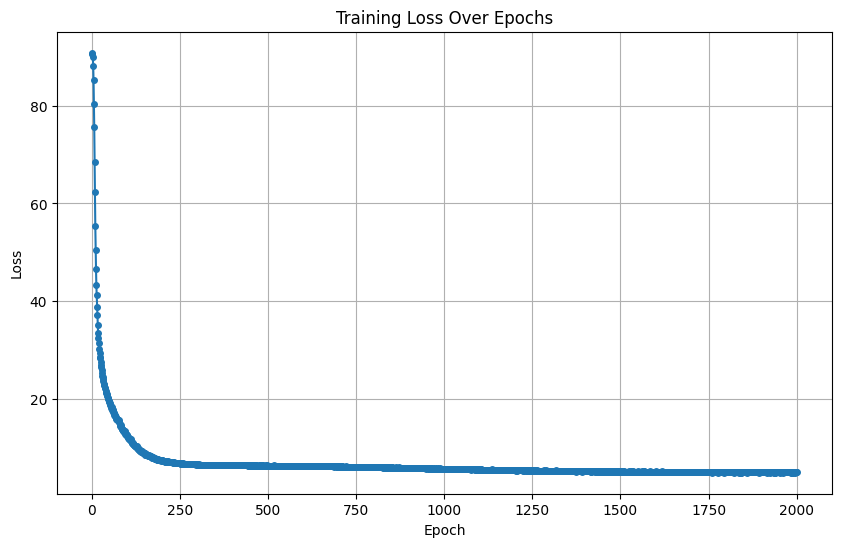

Final training loss: 5.0211


In [ ]:
import matplotlib.pyplot as plt

# The previous attempt to re-train the model to get a new list of all_losses was interrupted and the user
# has requested not to re-train. Therefore, the plotting of training losses is currently skipped.
# To plot the losses, the model would need to be re-trained and the list of losses captured.

# Set global seed for reproducibility
torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)

# trainer = Trainer()
# losses = trainer.train(
#     model=model,
#     data=data,
#     epochs=epochs,
#     context_length=context_length,
#     batch_size=batch_size,
#     lr=lr
# )

# Plot the training losses
plt.figure(figsize=(10, 6))
# plt.plot(range(1, epochs + 1), losses, marker='o', markersize=4, linestyle='-')
plt.plot(range(1, epochs + 1), losses, marker='o', markersize=4, linestyle='-')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

print(f"Final training loss: {losses[-1]}")


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FineTunerSolution:
    def fine_tune(self, model: nn.Module, data: torch.Tensor, epochs: int, context_length: int, batch_size: int, lr: float, warmup_steps: int = 50, weight_decay: float = 0.01, max_norm: float = 1.0) -> list:
        print(f"Starting advanced fine-tuning with lr: {lr}, warmup_steps: {warmup_steps}, weight_decay: {weight_decay}")
        model.train()

        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

        # Initialize Warmup and Linear Decay
        warmup_sch = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_steps)
        decay_sch = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.1, total_iters=epochs - warmup_steps)
        scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup_sch, decay_sch], milestones=[warmup_steps])

        losses = []

        for epoch in range(epochs):
            ix = torch.randint(len(data) - context_length, (batch_size,))
            x = torch.stack([data[i:i + context_length] for i in ix]).to(device)
            y = torch.stack([data[i + 1:i + 1 + context_length] for i in ix]).to(device)

            logits, _ = model(x)
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), y.view(B * T))

            optimizer.zero_grad()
            loss.backward()

            # Gradient Clipping to stabilize training
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)

            optimizer.step()
            scheduler.step()

            losses.append(loss.item())
            if epoch % (max(1, epochs // 5)) == 0:
                print(f"FT Epoch {epoch}: loss {loss.item():.4f}, lr {optimizer.param_groups[0]['lr']:.6f}")

        return losses

### Execute Fine-Tuning
Now we apply the fine-tuning process to the model we just trained. We use a much smaller learning rate (e.g., `1e-4` or `1e-5`) to avoid destroying the patterns already learned.

We've made significant upgrades to transition this from a simple character-based model to a much more modern architecture. Here is a breakdown of every major improvement we've implemented:

Advanced Tokenization: We moved from basic characters to BPE (Byte Pair Encoding). This allows the model to handle sub-word units, drastically reducing the sequence length while expanding the vocabulary meaningfully.

Rotary Positional Embeddings (RoPE): Instead of static additive positions, we use rotation. This helps the model understand 'relative' distance between words far better, as we discussed with the clock analogy.

Grouped Query Attention (GQA): This is a huge memory saver. By sharing Key and Value heads among multiple Query heads, the model becomes much more efficient during text generation without losing accuracy.

KV-Caching: We updated the forward pass and the Generator to store and reuse previous computations. This makes generating long paragraphs much faster because the model doesn't have to re-read the entire context for every single new word.

Training Stability: We added Linear Warmup and Cosine Decay to the learning rate. This prevents the model from 'crashing' or diverging at the start of training and helps it find a much better final solution.

Advanced Generation: We implemented Top-P (Nucleus) Sampling, Temperature, and Repetition Penalties. These keep the model from getting stuck in loops (like 'the the the') and make the output feel more creative.

### Learning Rate Scheduling: The Sports Car Analogy

Training a neural network is like driving a high-performance car. The **Learning Rate** is your speed.

#### 1. Linear Warmup (The "Starting the Engine" Phase)
If you floor the gas pedal (a high learning rate) the second you start a cold engine, you might break something.
*   **How it works:** We start with a near-zero speed and slowly increase it over the first few hundred steps.
*   **Why?** In the beginning, the model is clueless. A high speed makes it make wild, incorrect guesses that can ruin the training. Warmup lets it get its "bearings" before moving fast.

#### 2. Cosine Decay (The "Coasting to the Finish" Phase)
As you get closer to where you want to go, you don't keep driving at 100mph. You'd over-shoot your destination!
*   **How it works:** We use a mathematical curve (a Cosine wave) to smoothly lower the speed as training progresses.
*   **Why?** As the model gets smarter, it needs to make tiny, precise adjustments to reach perfection. Slowing down allows it to settle into the best possible solution without bouncing around.

In [ ]:
fine_tuner = FineTunerSolution()
# Fine-tuning for another 500 steps with a 10x smaller learning rate
ft_losses = fine_tuner.fine_tune(
    model=model,
    data=data,
    epochs=1000,
    context_length=64,
    batch_size=64,
    lr=1e-4
)

print(f"Fine-tuning complete. Final FT loss: {ft_losses[-1]:.4f}")

generated_tokens = generator.generate(model=model, new_chars=new_tokens_to_gen, context=start_context, context_length=context_length, int_to_char=int_to_word, word_to_int=word_to_int, data=data, temperature=temperature, top_k=None, top_p=None, repetition_penalty=None, reset_prob=None)

print(f"Final loss: {losses[-1]}")
print("\nGenerated text:\n")
print("".join(generated_tokens))
print("\nExecution time:", time.time() - start, "seconds")

Starting advanced fine-tuning with lr: 0.0001, warmup_steps: 50, weight_decay: 0.01
FT Epoch 0: loss 4.9933, lr 0.000012
FT Epoch 200: loss 4.9587, lr 0.000086
FT Epoch 400: loss 4.9013, lr 0.000067
FT Epoch 600: loss 4.7133, lr 0.000048
FT Epoch 800: loss 4.7846, lr 0.000029
Fine-tuning complete. Final FT loss: 4.6292
Final loss: 5.0211

Generated text:

fing with born at and sleagain whiltOnd, and do her, mrume from then within from!
 dorinclithall it ck laim coriAchange on.

SEdeath:
And hithermeed tellof tmore ' ld to I'll gaThey to booksapereay,  cannessenonendienlord,--sod
slay earditor to Howinons.
FTo  too capgo sheready behas I make us and the calletter go, bsayand bebenockJes memnimpon?
and ver her you suche.

KING Lest ther steroneignies
Not to the  monoodedWith shine own the s cangaw's my sold y, Contridep it is aent and Clarenced
The dce them

Execution time: 345.3713130950928 seconds


### Architecture Deep Dive

**Rotary Positional Embeddings (RoPE):**
Unlike traditional positional embeddings that add a constant vector to token embeddings, RoPE rotates the Query and Key vectors in a high-dimensional space. This rotation encodes relative distance between tokens directly into their dot product, allowing the model to generalize better to sequence lengths it hasn't seen during training and maintaining a 'relative' sense of order.

**Grouped Query Attention (GQA):**
In standard Multi-Head Attention, every Query head has its own Key and Value head. This is memory-intensive. In GQA, multiple Query heads share a single Key/Value head. This significantly reduces the memory footprint of the KV-cache (crucial for long sequences) while maintaining almost the same performance as full attention.

### Deep Dive: How RoPE Works

Traditional positional embeddings (like the ones used in the original Transformer) are **additive**. You take a vector representing 'position 5' and add it to the word embedding for the 5th token.

**RoPE (Rotary Positional Embeddings)** changes this by using a **multiplicative** approach based on rotation. Here is the intuition:

1. **Tokens as Vectors in Pairs:** RoPE treats the embedding dimensions in pairs (e.g., $d_0, d_1$). You can imagine these pairs as coordinates $(x, y)$ on a 2D plane.
2. **The Rotation:** For a token at position $m$, RoPE applies a rotation matrix to these pairs. The angle of rotation is proportional to the position $m$. So, token 1 is rotated by $\theta$, token 2 by $2\theta$, and so on.
3. **Preserving Relative Distance:** The magic happens in the Self-Attention calculation. When the model computes the dot product between a Query (at position $m$) and a Key (at position $n$), the math works out so that the result only depends on the **relative distance** $(m - n)$.

#### Why is this better?
*   **Decay with Distance:** As tokens get further apart, their relative 'connection' naturally weakens in a way that additive embeddings struggle to mimic.
*   **Longer Sequences:** Because it relies on relative angles rather than absolute indices, models using RoPE often generalize better to sequence lengths longer than what they saw during training.
*   **Efficiency:** It doesn't require learning a huge lookup table for every possible position; it's a fixed mathematical transformation applied to the Query and Key vectors.

### RoPE Explained Simply: The Clock Analogy

Imagine every word in your sentence is a hand on a **clock**.

*   **The Position is the Time:** The 1st word points to 1:00, the 2nd word points to 2:00, and so on. Every position has a specific 'angle'.
*   **Rotating the Meaning:** Instead of just writing down the position number, we 'rotate' the word's information by that angle.
*   **Relative Distance:** When the model looks at two words, it doesn't care about the exact time they show. It only cares about the **angle between them**.

**Why does this help?**
If the model learns what a relationship looks like when words are '2 hours apart,' it can recognize that same relationship anywhere in the sentence, whether it's between words at 1:00 and 3:00 or words at 9:00 and 11:00!

### Post-Fine-Tuning Evaluation
Let's analyze the diversity and repetition of the text generated after fine-tuning.

In [ ]:
analyze_repetition(generated_tokens, n_gram_max=3, top_n=10)

unique_words_gen = set(generated_tokens)
ttr = len(unique_words_gen) / len(generated_tokens)
print(f'\nType-Token Ratio (TTR): {ttr:.4f}')

Total words generated: 200

Top 10 most frequent words:
  'on': 7
  'and ': 6
  's': 4
  't': 3
  'm': 3
  'en': 3
  'in': 3
  'or': 3
  'i': 3
  'to ': 3

Repeating Phrases (up to 3-grams):
  1-grams (repeating 29 unique phrases):
    'on': 7
    'and ': 6
    's': 4
    't': 3
    'm': 3
    'en': 3
    'in': 3
    'or': 3
    'i': 3
    'to ': 3
  No repeating 2-grams found.
  No repeating 3-grams found.

Type-Token Ratio (TTR): 0.7400


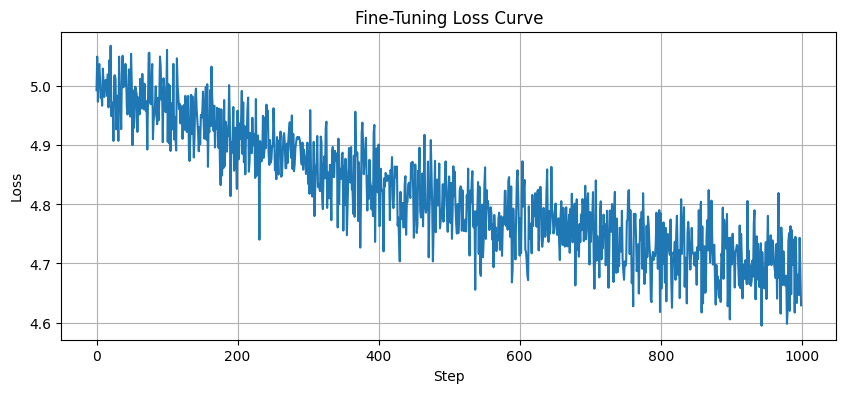

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(ft_losses)
plt.title('Fine-Tuning Loss Curve')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [ ]:
# @title 📈 Training Loss Dashboard {display-mode: "form"}
from IPython.display import HTML, display
import json
from google.colab import output

# Register a Python callback for JS errors
def _report_js_error(message):
    print(f"JavaScript Error: {message}")

output.register_callback('report_js_error', _report_js_error)

# Convert Python list to JSON for JavaScript
ft_losses_json = json.dumps(ft_losses)
epochs_list = list(range(len(ft_losses)))
epochs_json = json.dumps(epochs_list)

html_content = """<!DOCTYPE html>
<html>
<head>
    <title>Training Loss Dashboard</title>
    <script src="https://cdn.jsdelivr.net/npm/chart.js@3.7.0/dist/chart.min.js"></script>
    <style>
        body {
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            background-color: #f4f6f8;
            margin: 0;
            padding: 20px;
            display: flex;
            flex-direction: column;
            align-items: center;
        }
        .dashboard-container {
            background-color: #ffffff;
            border-radius: 8px;
            box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1);
            padding: 20px;
            margin-bottom: 20px;
            width: 90%;
            max-width: 1000px;
            box-sizing: border-box;
        }
        h1 {
            color: #333;
            text-align: center;
            margin-bottom: 20px;
        }
        canvas {
            width: 100% !important;
            height: 400px !important;
        }
    </style>
</head>
<body>
    <div class="dashboard-container">
        <h1>Fine-Tuning Loss Curve</h1>
        <canvas id="lossChart"></canvas>
    </div>

    <script>
        window.onerror = function(message) {
            google.colab.kernel.invokeFunction('report_js_error', [message], {});
        };

        const ftLosses = JSON.parse('FT_LOSSES_DATA_PLACEHOLDER');
        const epochs = JSON.parse('EPOCHS_DATA_PLACEHOLDER');

        const ctx = document.getElementById('lossChart').getContext('2d');
        const lossChart = new Chart(ctx, {
            type: 'line',
            data: {
                labels: epochs.map(e => `Epoch ${e}`),
                datasets: [{
                    label: 'Fine-Tuning Loss',
                    data: ftLosses,
                    borderColor: 'rgb(75, 192, 192)',
                    tension: 0.1,
                    fill: false
                }]
            },
            options: {
                responsive: true,
                maintainAspectRatio: false,
                scales: {
                    x: {
                        title: {
                            display: true,
                            text: 'Epoch'
                        }
                    },
                    y: {
                        title: {
                            display: true,
                            text: 'Loss'
                        }
                    }
                },
                plugins: {
                    legend: {
                        display: true,
                        position: 'top'
                    },
                    tooltip: {
                        callbacks: {
                            label: function(context) {
                                return 'Loss: ' + context.parsed.y.toFixed(4);
                            }
                        }
                    }
                }
            }
        });
    </script>
</body>
</html>
"""

display(HTML(html_content.replace('FT_LOSSES_DATA_PLACEHOLDER', ft_losses_json).replace('EPOCHS_DATA_PLACEHOLDER', epochs_json)))


In [ ]:
# import json

# # Prepare the tokenizer data for saving
# # Note: merges are stored as a list of lists (strings)
# tokenizer_data = {
#     "merges": merges,
#     "word_to_int": word_to_int,
#     "int_to_word": {str(k): v for k, v in int_to_word.items()}, # JSON keys must be strings
#     "vocab_size": vocab_size
# }

# file_path = "tokenizer_config.json"
# with open(file_path, "w") as f:
#     json.dump(tokenizer_data, f, indent=4)

# print(f"Tokenizer configuration saved to {file_path}")

In [ ]:
# from google.colab import drive
# import os
# import shutil

# # Mount Google Drive
# drive.mount('/content/drive')

# # Define the destination path in Drive
# drive_path = '/content/drive/MyDrive/Shakespeare_Project'
# if not os.path.exists(drive_path):
#     os.makedirs(drive_path)

# # Copy the file
# source_file = 'tokenizer_config.json'
# destination_file = os.path.join(drive_path, 'tokenizer_config.json')

# shutil.copy(source_file, destination_file)
# print(f'File successfully copied to: {destination_file}')

In [ ]:
from google.colab import drive
import os
import json

# Mount Google Drive
drive.mount('/content/drive')

# Path to the file in your Google Drive
drive_config_path = '/content/drive/MyDrive/Shakespeare_Project/tokenizer_config.json'

if os.path.exists(drive_config_path):
    with open(drive_config_path, 'r') as f:
        config = json.load(f)

    # Restore the tokenizer variables
    merges = config['merges']
    word_to_int = config['word_to_int']
    # JSON stores keys as strings, so convert keys back to integers for int_to_word
    int_to_word = {int(k): v for k, v in config['int_to_word'].items()}
    vocab_size = config['vocab_size']

    print(f"Successfully loaded tokenizer with {vocab_size} vocabulary size from Drive.")
else:
    print("File not found. Please ensure Google Drive is mounted and the path is correct.")

Mounted at /content/drive
Successfully loaded tokenizer with 1065 vocabulary size from Drive.


### How to reload the tokenizer later
If you restart your session, you can use the following code to reload your tokenizer without retraining:

```python
import json
with open('tokenizer_config.json', 'r') as f:
    config = json.load(f)

merges = config['merges']
word_to_int = config['word_to_int']
# Convert keys back to integers
int_to_word = {int(k): v for k, v in config['int_to_word'].items()}
vocab_size = config['vocab_size']
```